# Modeling dan Hyperparameter Tuning
## 04 — Membandingkan Model pada Validasi Berdasarkan Waktu

**Proyek:** Prediksi Muka Air Tanah Satu Minggu ke Depan · **Penyusun:** Rasen

Setelah memahami data dan membuat fitur, saya mulai menguji apakah model dapat memperkirakan head minggu depan lebih baik daripada baseline. Saya membandingkan beberapa jenis model dan kelompok fitur, lalu mencoba tuning terbatas pada kandidat yang paling menjanjikan.

Notebook ini menghasilkan perbandingan validasi, kandidat ML yang dikunci, serta pipeline yang dilatih pada data pengembangan. **Holdout belum dibuka untuk penilaian akhir.** Tahap setelah ini adalah evaluasi akhir pada notebook 05, baru dashboard Streamlit dan dokumentasi proyek.

### Hubungan dengan materi bootcamp

| Materi | Penerapan pada proyek |
| --- | --- |
| Preprocessing dan cleaning | Notebook 01 dan pemeriksaan fitur di notebook 03 |
| Visualisasi dan EDA | Notebook 02 |
| Supervised modeling | Delapan algoritma regresi pada notebook ini |
| Pemilihan fitur | Perbandingan head-only, head+cuaca, dan tambahan musim |
| Hyperparameter tuning | Pencarian kecil pada tiga keluarga model terbaik di validasi |
| Deployment Streamlit | Tahap berikutnya setelah evaluasi akhir |

PCA dan clustering tidak dipaksakan. Tujuan utamanya adalah regresi deret waktu, dan pemilihan fitur di sini dilakukan dengan membandingkan kelompok fitur. Model lebih rumit tidak otomatis lebih baik.

### Cara menjalankan

Jalankan notebook 03 terlebih dahulu, lalu notebook ini dari atas ke bawah. Cell perbandingan model dan tuning akan lebih lama daripada EDA; progres ditampilkan per eksperimen. Tunggu sampai nomor eksekusinya selesai, jangan menjalankan cell yang sama berulang-ulang saat masih bekerja.

Jika muncul `ModuleNotFoundError`, tambahkan cell sementara berisi `%pip install scikit-learn joblib`, jalankan pada kernel yang sama, restart kernel, lalu Run All lagi. Tidak perlu mengganti Python hanya untuk notebook ini.

Output lama bernama sama di `outputs/modeling` dan `models` akan ditimpa saat notebook dijalankan ulang. CSV sumber dan holdout tidak diubah.


## 1. Membaca Data Pengembangan dan Definisi Fitur

Notebook ini hanya membaca `netherlands_development.csv`. Tanggal tetap digunakan untuk menentukan pembagian latihan dan validasi. Kolom input diambil dari daftar fitur yang dibuat notebook sebelumnya, sehingga target, tanggal target, dan penanda kelengkapan tidak ikut menjadi input.

Versi pustaka dicatat agar hasil lebih mudah ditelusuri. Skor dapat sedikit berbeda antarversi dan perangkat meskipun seed sudah ditetapkan.


In [1]:
from pathlib import Path
import json
import hashlib
import time
import warnings
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import sklearn
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import ParameterGrid
from sklearn.exceptions import ConvergenceWarning

kandidat = [Path.cwd(), *Path.cwd().parents,
    Path.home()/"Downloads"/"Rasen_Portofolio"/"02_Projects"/"groundwater_forecasting"]
PROJECT_DIR = next((p for p in kandidat if (p/"data/processed/feature_schema.json").is_file()), None)
if PROJECT_DIR is None:
    raise FileNotFoundError("feature_schema.json belum ada. Jalankan notebook 03 terlebih dahulu.")
DATA_DIR = PROJECT_DIR/"data/processed"
OUTPUT_DIR = PROJECT_DIR/"outputs/modeling"
MODEL_DIR = PROJECT_DIR/"models"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
skema = json.loads((DATA_DIR/"feature_schema.json").read_text(encoding="utf-8"))
file_dev = DATA_DIR/"netherlands_development.csv"
assert hashlib.sha256(file_dev.read_bytes()).hexdigest() == skema["development_sha256"], "CSV berubah setelah skema dibuat. Jalankan ulang notebook 03."
dev = pd.read_csv(file_dev, parse_dates=["forecast_date", "target_date"]).sort_values("target_date").reset_index(drop=True)
kelompok_fitur = skema["feature_groups"]
TARGET = skema["target_column"]
BATAS_HOLDOUT = pd.Timestamp(skema["holdout_target_start"])
assert len(dev) > 0 and not dev["target_date"].duplicated().any()
assert (dev["target_date"] < BATAS_HOLDOUT).all()
assert (dev["target_date"] - dev["forecast_date"]).eq(pd.Timedelta(weeks=1)).all()
assert dev[kelompok_fitur["head_weather_season"]+[TARGET]].notna().all().all()
assert not np.isinf(dev[kelompok_fitur["head_weather_season"]+[TARGET]].to_numpy()).any()
assert TARGET not in set(sum(kelompok_fitur.values(), []))
SEED = 42
versi = {"python": platform.python_version(), "sklearn": sklearn.__version__,
    "pandas": pd.__version__, "numpy": np.__version__, "joblib": joblib.__version__}
print("Versi:", versi)
print("Sampel pengembangan:", len(dev))
print("Holdout tidak dibaca oleh notebook ini.")


Versi: {'python': '3.13.5', 'sklearn': '1.6.1', 'pandas': '2.2.3', 'numpy': '2.1.3', 'joblib': '1.4.2'}
Sampel pengembangan: 804
Holdout tidak dibaca oleh notebook ini.


## 2. Menentukan Validasi Deret Waktu

Saya memakai empat periode validasi dua tahunan: 2009–2010, 2011–2012, 2013–2014, dan 2015–2016. Bagian latihan bertambah pada fold berikutnya, tetapi selalu berasal dari masa sebelumnya. Periode ini ditetapkan sebelum melihat skor.

Saya membuat fold berdasarkan tanggal, bukan membagi baris secara acak. Setelah sampel tidak lengkap disaring, jarak antarbaris bisa lebih dari seminggu. Karena itu, pembagian berdasarkan kalender lebih mudah dibaca dan diaudit.

Target latihan harus lebih awal daripada waktu prediksi pertama pada fold validasi. Pembatasan ini sengaja konservatif agar tidak ada target latihan yang menyentuh awal periode prediksi. Fold 2015–2016 memiliki lebih sedikit sampel karena gap; cakupannya ditampilkan.

Pada tiap fold, model dilatih sekali lalu digunakan untuk prediksi satu minggu ke depan pada setiap waktu yang tersedia. Input validasi boleh menggunakan pengamatan historis yang sudah diketahui pada minggu tersebut. Jadi, ini evaluasi prediksi satu langkah bergulir, bukan ramalan banyak tahun sekaligus.


In [2]:
rentang_validasi = [("2009-01-01", "2011-01-01"), ("2011-01-01", "2013-01-01"),
                    ("2013-01-01", "2015-01-01"), ("2015-01-01", "2017-01-01")]
folds = []
catatan_fold = []
for nomor, (awal, akhir) in enumerate(rentang_validasi, start=1):
    idx_val = np.flatnonzero(dev["target_date"].ge(pd.Timestamp(awal)) & dev["target_date"].lt(pd.Timestamp(akhir)))
    if len(idx_val) < 20:
        raise ValueError(f"Fold {nomor} memiliki kurang dari 20 sampel. Tinjau cakupan data; jangan mengubah rentang demi skor.")
    waktu_prediksi_pertama = dev.iloc[idx_val]["forecast_date"].min()
    idx_train = np.flatnonzero(dev["target_date"] < waktu_prediksi_pertama)
    assert len(idx_train) >= 100
    assert dev.iloc[idx_train]["target_date"].max() < waktu_prediksi_pertama
    folds.append((idx_train, idx_val))
    catatan_fold.append({"fold": nomor, "n_train": len(idx_train), "n_validasi": len(idx_val),
        "akhir_target_train": dev.iloc[idx_train]["target_date"].max().date(),
        "awal_forecast_validasi": waktu_prediksi_pertama.date(),
        "awal_target_validasi": dev.iloc[idx_val]["target_date"].min().date(),
        "akhir_target_validasi": dev.iloc[idx_val]["target_date"].max().date()})
tabel_fold = pd.DataFrame(catatan_fold)
display(tabel_fold)
idx_oof = np.concatenate([v for _, v in folds])
assert len(idx_oof) == len(set(idx_oof))


,fold,n_train,n_validasi,akhir_target_train,awal_forecast_validasi,awal_target_validasi,akhir_target_validasi
0,1,445,104,2008-12-21,2008-12-28,2009-01-04,2010-12-26
1,2,549,105,2010-12-19,2010-12-26,2011-01-02,2012-12-30
2,3,654,104,2012-12-23,2012-12-30,2013-01-06,2014-12-28
3,4,758,45,2014-12-21,2014-12-28,2015-01-04,2016-12-25


## 3. Menetapkan Metrik dan Baseline

**MAE** menjadi metrik utama: rata-rata besar kesalahan dalam meter. Misalnya MAE 0,03 m berarti rata-rata kesalahan absolut 3 cm pada sampel yang dinilai. **RMSE** memberi bobot lebih besar pada kesalahan besar. **R²** menjadi pelengkap dan dapat bernilai negatif; jangan menyebutnya persentase akurasi.

Skor utama dihitung dari gabungan semua prediksi validasi (out-of-fold/OOF), sehingga setiap minggu memiliki bobot sama. Skor per fold tetap disimpan untuk melihat kestabilan. Ini berbeda dari merata-ratakan skor empat fold yang ukuran sampelnya tidak sama.

Seasonal naïve dinilai terpisah bila cakupannya tidak penuh. Skornya tidak dimasukkan ke peringkat utama dengan tanggal berbeda. Perbandingan pada irisan tanggal dibuat setelah seluruh model tersedia.


In [3]:
def hitung_metrik(y, pred):
    y = np.asarray(y, dtype=float)
    pred = np.asarray(pred, dtype=float)
    assert len(y) == len(pred) and np.isfinite(y).all() and np.isfinite(pred).all()
    return {"n": len(y), "MAE_m": float(mean_absolute_error(y, pred)),
            "RMSE_m": float(np.sqrt(mean_squared_error(y, pred))),
            "R2": float(r2_score(y, pred)) if len(y) > 1 and np.var(y) > 0 else np.nan}

baseline_oof = dev.iloc[idx_oof][["forecast_date", "target_date", TARGET,
    "baseline_persistence", "baseline_seasonal_52w"]].copy().reset_index(drop=True)
metrik_persistence = hitung_metrik(baseline_oof[TARGET], baseline_oof["baseline_persistence"])
musiman_tersedia = baseline_oof["baseline_seasonal_52w"].notna()
tabel_baseline = pd.DataFrame([
    {"model": "Persistence", "cakupan": "seluruh tanggal OOF", **metrik_persistence},
    {"model": "Seasonal naive 52w", "cakupan": "hanya riwayat musiman tersedia",
     **hitung_metrik(baseline_oof.loc[musiman_tersedia, TARGET], baseline_oof.loc[musiman_tersedia, "baseline_seasonal_52w"])}
])
display(tabel_baseline.round(4))
print("Baseline musiman tersedia pada", int(musiman_tersedia.sum()), "dari", len(baseline_oof), "tanggal OOF.")


,model,cakupan,n,MAE_m,RMSE_m,R2
0,Persistence,seluruh tanggal OOF,358,0.0334,0.0506,0.7188
1,Seasonal naive 52w,hanya riwayat musiman tersedia,350,0.0802,0.1217,-0.5951


Baseline musiman tersedia pada 350 dari 358 tanggal OOF.


## 4. Menyiapkan Delapan Model

| Model | Hal yang diuji |
| --- | --- |
| Linear Regression | Hubungan linear sebagai model awal |
| Ridge | Model linear dengan regularisasi |
| KNN Regressor | Prediksi berdasarkan kondisi historis yang mirip |
| SVR | Hubungan nonlinear menggunakan kernel |
| Decision Tree | Aturan bercabang dengan pembatasan kompleksitas |
| Random Forest | Gabungan banyak pohon |
| Gradient Boosting | Pohon yang memperbaiki kesalahan secara bertahap |
| MLP Regressor | Jaringan saraf kecil pada fitur tabular |

Scaling input berada di dalam pipeline, sehingga hanya mempelajari statistik bagian latihan setiap fold. Model pohon tidak membutuhkan scaling. SVR dan MLP juga menggunakan standardisasi target melalui `TransformedTargetRegressor`; prediksi dikembalikan ke meter secara otomatis.

MLP memakai jaringan kecil, solver L-BFGS, dan tanpa early stopping acak. Peringatan konvergensi dicatat. Eksperimen yang belum konvergen pada salah satu fold tidak dipilih sebagai kandidat akhir, walaupun skornya terlihat menarik.


In [4]:
def model_dasar():
    def berskala(model):
        return Pipeline([("scale", StandardScaler()), ("model", model)])
    return {
        "LinearRegression": berskala(LinearRegression()),
        "Ridge": berskala(Ridge(alpha=10.0)),
        "KNN": berskala(KNeighborsRegressor(n_neighbors=15, weights="distance")),
        "SVR": TransformedTargetRegressor(
            regressor=berskala(SVR(C=1.0, epsilon=.1)), transformer=StandardScaler()),
        "DecisionTree": DecisionTreeRegressor(max_depth=4, min_samples_leaf=10, random_state=SEED),
        "RandomForest": RandomForestRegressor(n_estimators=120, max_depth=8,
            min_samples_leaf=4, random_state=SEED, n_jobs=1),
        "GradientBoosting": GradientBoostingRegressor(n_estimators=120,
            learning_rate=.05, max_depth=2, min_samples_leaf=5, random_state=SEED),
        "MLP": TransformedTargetRegressor(
            regressor=berskala(MLPRegressor(hidden_layer_sizes=(8,), solver="lbfgs",
                alpha=1.0, max_iter=2000, max_fun=20000, random_state=SEED)),
            transformer=StandardScaler())
    }

model_awal = model_dasar()
cache_oof = {}
log_fold = []
log_warning = []

def evaluasi_cv(estimator, nama_model, nama_fitur, experiment_id, tahap):
    kolom = kelompok_fitur[nama_fitur]
    prediksi_fold = []
    jumlah_konvergensi = 0
    mulai = time.perf_counter()
    for nomor, (idx_train, idx_val) in enumerate(folds, start=1):
        model = clone(estimator)
        train, val = dev.iloc[idx_train], dev.iloc[idx_val]
        with warnings.catch_warnings(record=True) as daftar_warning:
            warnings.simplefilter("always")
            model.fit(train[kolom], train[TARGET])
            pred = model.predict(val[kolom])
        for w in daftar_warning:
            if issubclass(w.category, ConvergenceWarning):
                jumlah_konvergensi += 1
            log_warning.append({"experiment_id": experiment_id, "fold": nomor,
                "jenis": w.category.__name__, "pesan": str(w.message)})
        metrik_val = hitung_metrik(val[TARGET], pred)
        train_mae = mean_absolute_error(train[TARGET], model.predict(train[kolom]))
        log_fold.append({"experiment_id": experiment_id, "model": nama_model,
            "kelompok_fitur": nama_fitur, "tahap": tahap, "fold": nomor,
            "train_MAE_m": float(train_mae), **metrik_val})
        frame = val[["forecast_date", "target_date", TARGET]].copy()
        frame["prediksi_m"] = pred
        frame["fold"] = nomor
        prediksi_fold.append(frame)
    oof = pd.concat(prediksi_fold).sort_values("target_date").reset_index(drop=True)
    assert oof["target_date"].equals(baseline_oof["target_date"])
    cache_oof[experiment_id] = oof
    skor = hitung_metrik(oof[TARGET], oof["prediksi_m"])
    return {"experiment_id": experiment_id, "model": nama_model, "kelompok_fitur": nama_fitur,
        "tahap": tahap, "n_fitur": len(kolom), **skor,
        "skill_vs_persistence_pct": 100*(1-skor["MAE_m"]/metrik_persistence["MAE_m"]),
        "convergence_warnings": jumlah_konvergensi,
        "durasi_detik": time.perf_counter()-mulai}


## 5. Membandingkan Model dan Kelompok Fitur

Ada 8 model × 3 kelompok fitur, sehingga terdapat 24 eksperimen awal. Masing-masing dinilai pada empat fold waktu yang sama. Ini sekaligus menjadi percobaan pemilihan kelompok fitur: apakah cuaca atau musim membantu dibanding riwayat head saja?

`skill_vs_persistence_pct` menunjukkan pengurangan MAE relatif terhadap persistence. Nilai positif berarti MAE lebih rendah; nilai negatif berarti lebih buruk. Angka ini bukan persentase akurasi.

Jika muncul peringatan konvergensi, lihat file catatan warning setelah proses selesai. Jika ada error sebenarnya, proses dihentikan agar hasil yang tidak lengkap tidak disajikan sebagai perbandingan penuh.


In [5]:
hasil_awal = []
registry = {}
total = len(model_awal)*len(kelompok_fitur)
nomor = 0
for nama_model, estimator in model_awal.items():
    for nama_fitur in kelompok_fitur:
        nomor += 1
        experiment_id = f"awal_{nama_model}_{nama_fitur}"
        print(f"[{nomor}/{total}] {nama_model} — {nama_fitur}", flush=True)
        hasil = evaluasi_cv(estimator, nama_model, nama_fitur, experiment_id, "awal")
        registry[experiment_id] = clone(estimator)
        hasil_awal.append(hasil)
        print(f"  MAE: {hasil['MAE_m']:.4f} m; warning konvergensi: {hasil['convergence_warnings']}", flush=True)
peringkat_awal = pd.DataFrame(hasil_awal).sort_values(["MAE_m", "RMSE_m", "n_fitur"]).reset_index(drop=True)
display(peringkat_awal[["model", "kelompok_fitur", "MAE_m", "RMSE_m", "R2",
    "skill_vs_persistence_pct", "convergence_warnings"]].round(4))


[1/24] LinearRegression — head_only
  MAE: 0.0324 m; warning konvergensi: 0
[2/24] LinearRegression — head_weather
  MAE: 0.0297 m; warning konvergensi: 0
[3/24] LinearRegression — head_weather_season
  MAE: 0.0299 m; warning konvergensi: 0
[4/24] Ridge — head_only
  MAE: 0.0320 m; warning konvergensi: 0
[5/24] Ridge — head_weather
  MAE: 0.0294 m; warning konvergensi: 0
[6/24] Ridge — head_weather_season
  MAE: 0.0295 m; warning konvergensi: 0
[7/24] KNN — head_only
  MAE: 0.0319 m; warning konvergensi: 0
[8/24] KNN — head_weather
  MAE: 0.0313 m; warning konvergensi: 0
[9/24] KNN — head_weather_season


  File "c:\Users\MSI MODERN\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\MSI MODERN\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\MSI MODERN\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\MSI MODERN\anaco

  MAE: 0.0317 m; warning konvergensi: 0
[10/24] SVR — head_only
  MAE: 0.0324 m; warning konvergensi: 0
[11/24] SVR — head_weather
  MAE: 0.0270 m; warning konvergensi: 0
[12/24] SVR — head_weather_season
  MAE: 0.0266 m; warning konvergensi: 0
[13/24] DecisionTree — head_only
  MAE: 0.0335 m; warning konvergensi: 0
[14/24] DecisionTree — head_weather
  MAE: 0.0358 m; warning konvergensi: 0
[15/24] DecisionTree — head_weather_season
  MAE: 0.0367 m; warning konvergensi: 0
[16/24] RandomForest — head_only
  MAE: 0.0321 m; warning konvergensi: 0
[17/24] RandomForest — head_weather
  MAE: 0.0287 m; warning konvergensi: 0
[18/24] RandomForest — head_weather_season
  MAE: 0.0288 m; warning konvergensi: 0
[19/24] GradientBoosting — head_only
  MAE: 0.0318 m; warning konvergensi: 0
[20/24] GradientBoosting — head_weather
  MAE: 0.0281 m; warning konvergensi: 0
[21/24] GradientBoosting — head_weather_season
  MAE: 0.0279 m; warning konvergensi: 0
[22/24] MLP — head_only
  MAE: 0.0318 m; warnin

,model,kelompok_fitur,MAE_m,RMSE_m,R2,skill_vs_persistence_pct,convergence_warnings
0,SVR,head_weather_season,0.0266,0.0394,0.8295,20.3288,0
1,SVR,head_weather,0.0270,0.0397,0.8266,19.1379,0
2,GradientBoosting,head_weather_season,0.0279,0.0431,0.7958,16.4322,0
3,GradientBoosting,head_weather,0.0281,0.0435,0.7917,15.7548,0
4,MLP,head_weather,0.0282,0.0436,0.7905,15.3150,0
5,MLP,head_weather_season,0.0283,0.0431,0.7955,15.2524,0
6,RandomForest,head_weather,0.0287,0.0440,0.7872,13.9263,0
7,RandomForest,head_weather_season,0.0288,0.0442,0.7854,13.5645,0
8,Ridge,head_weather,0.0294,0.0445,0.7822,11.8521,0
9,Ridge,head_weather_season,0.0295,0.0445,0.7819,11.6203,0


### 5.1 Membaca Manfaat Tambahan Fitur

Tabel berikut menyandingkan MAE ketiga kelompok fitur untuk setiap algoritma. Jika penambahan cuaca menurunkan MAE pada model tertentu, berarti ada indikasi manfaat pada validasi ini. Jika justru naik, tambahan informasi belum tentu membantu dengan konfigurasi tersebut.

Semua kelompok memakai sampel yang sama. Meski demikian, pemilihan fitur dilakukan pada data pengembangan, sehingga skor ini belum menjadi hasil uji akhir yang independen.


kelompok_fitur,head_only,head_weather,head_weather_season
model,,,
DecisionTree,0.0335,0.0358,0.0367
GradientBoosting,0.0318,0.0281,0.0279
KNN,0.0319,0.0313,0.0317
LinearRegression,0.0324,0.0297,0.0299
MLP,0.0318,0.0282,0.0283
RandomForest,0.0321,0.0287,0.0288
Ridge,0.0320,0.0294,0.0295
SVR,0.0324,0.0270,0.0266


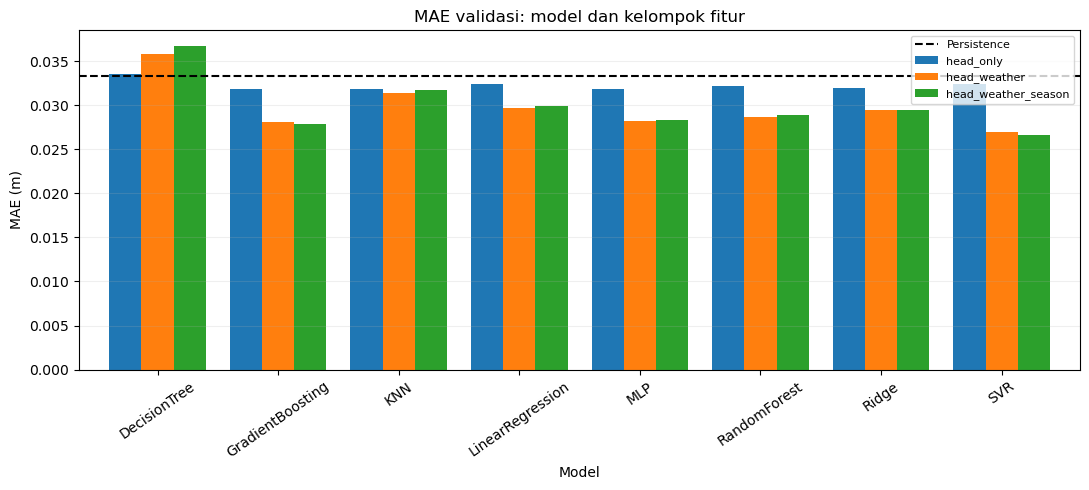

In [6]:
perbandingan_fitur = peringkat_awal.pivot(index="model", columns="kelompok_fitur", values="MAE_m")
display(perbandingan_fitur.round(4))
fig, ax = plt.subplots(figsize=(11, 5))
perbandingan_fitur.plot.bar(ax=ax, width=.8)
ax.axhline(metrik_persistence["MAE_m"], color="black", linestyle="--", label="Persistence")
ax.set(title="MAE validasi: model dan kelompok fitur", xlabel="Model", ylabel="MAE (m)")
ax.tick_params(axis="x", rotation=35)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=.2)
fig.tight_layout()
fig.savefig(OUTPUT_DIR/"01_perbandingan_model_fitur.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)


## 6. Tuning Terbatas pada Kandidat Terbaik

Saya memilih tiga keluarga model dengan MAE validasi terbaik yang tidak memiliki warning konvergensi. Untuk setiap keluarga, kelompok fitur terbaiknya dipertahankan, lalu beberapa parameter dicoba. Konfigurasi awal tetap menjadi kandidat sehingga tuning tidak otomatis mengganti model dengan hasil lebih buruk.

Pencarian dilakukan manual melalui `ParameterGrid` agar MAE gabungan seluruh tanggal OOF tetap menjadi ukuran pemilihan. Ini merupakan grid search dengan fold waktu yang sama, bukan pencarian pada holdout.

Rentangnya sengaja kecil untuk proyek pembelajaran dan laptop pribadi. Karena validasi yang sama dipakai untuk pemilihan sekaligus tuning, skor terbaik dapat optimistis. Itulah alasan evaluasi holdout masih diperlukan setelah pilihan dikunci.


In [7]:
ruang_parameter = {
    "LinearRegression": {"model__fit_intercept": [True, False]},
    "Ridge": {"model__alpha": [.1, 1., 10., 100.]},
    "KNN": {"model__n_neighbors": [5, 15, 30], "model__weights": ["uniform", "distance"]},
    "SVR": {"regressor__model__C": [.3, 3., 10.], "regressor__model__epsilon": [.05, .15]},
    "DecisionTree": {"max_depth": [3, 6], "min_samples_leaf": [5, 15]},
    "RandomForest": {"max_depth": [5, None], "min_samples_leaf": [2, 8]},
    "GradientBoosting": {"n_estimators": [80, 180], "max_depth": [1, 2]},
    "MLP": {"regressor__model__hidden_layer_sizes": [(8,), (16,)],
            "regressor__model__alpha": [1., 10.]}
}
kandidat_tuning = (peringkat_awal.loc[peringkat_awal["convergence_warnings"].eq(0)]
    .sort_values(["MAE_m", "RMSE_m", "n_fitur"])
    .drop_duplicates("model").head(3))
if len(kandidat_tuning) < 3:
    raise RuntimeError("Belum ada tiga keluarga model tanpa warning konvergensi. Periksa log terlebih dahulu.")
print("Kandidat tuning:")
display(kandidat_tuning[["model", "kelompok_fitur", "MAE_m"]])
hasil_tuning = []
parameter_eksperimen = {}
for _, calon in kandidat_tuning.iterrows():
    nama_model, nama_fitur = calon["model"], calon["kelompok_fitur"]
    daftar_parameter = list(ParameterGrid(ruang_parameter[nama_model]))
    for i, params in enumerate(daftar_parameter, start=1):
        experiment_id = f"tuning_{nama_model}_{i}"
        estimator = clone(model_awal[nama_model]).set_params(**params)
        print(f"Tuning {nama_model} [{i}/{len(daftar_parameter)}]: {params}", flush=True)
        hasil_tuning.append(evaluasi_cv(estimator, nama_model, nama_fitur, experiment_id, "tuning"))
        registry[experiment_id] = clone(estimator)
        parameter_eksperimen[experiment_id] = params

peringkat_semua = pd.concat([peringkat_awal, pd.DataFrame(hasil_tuning)], ignore_index=True)
peringkat_semua = peringkat_semua.sort_values(["MAE_m", "RMSE_m", "n_fitur"]).reset_index(drop=True)
layak_pilih = peringkat_semua.loc[peringkat_semua["convergence_warnings"].eq(0)]
terpilih = layak_pilih.iloc[0]
ID_TERPILIH = terpilih["experiment_id"]
FITUR_TERPILIH = kelompok_fitur[terpilih["kelompok_fitur"]]
display(peringkat_semua[["experiment_id", "MAE_m", "RMSE_m", "R2", "convergence_warnings"]].head(12).round(4))
print("Kandidat ML terkunci berdasarkan validasi:", ID_TERPILIH)


Kandidat tuning:


,model,kelompok_fitur,MAE_m
0,SVR,head_weather_season,0.026572
2,GradientBoosting,head_weather_season,0.027871
4,MLP,head_weather,0.028244


Tuning SVR [1/6]: {'regressor__model__C': 0.3, 'regressor__model__epsilon': 0.05}
Tuning SVR [2/6]: {'regressor__model__C': 0.3, 'regressor__model__epsilon': 0.15}
Tuning SVR [3/6]: {'regressor__model__C': 3.0, 'regressor__model__epsilon': 0.05}
Tuning SVR [4/6]: {'regressor__model__C': 3.0, 'regressor__model__epsilon': 0.15}
Tuning SVR [5/6]: {'regressor__model__C': 10.0, 'regressor__model__epsilon': 0.05}
Tuning SVR [6/6]: {'regressor__model__C': 10.0, 'regressor__model__epsilon': 0.15}
Tuning GradientBoosting [1/4]: {'max_depth': 1, 'n_estimators': 80}
Tuning GradientBoosting [2/4]: {'max_depth': 1, 'n_estimators': 180}
Tuning GradientBoosting [3/4]: {'max_depth': 2, 'n_estimators': 80}
Tuning GradientBoosting [4/4]: {'max_depth': 2, 'n_estimators': 180}
Tuning MLP [1/4]: {'regressor__model__alpha': 1.0, 'regressor__model__hidden_layer_sizes': (8,)}
Tuning MLP [2/4]: {'regressor__model__alpha': 1.0, 'regressor__model__hidden_layer_sizes': (16,)}
Tuning MLP [3/4]: {'regressor__model_

,experiment_id,MAE_m,RMSE_m,R2,convergence_warnings
0,tuning_MLP_3,0.0248,0.0377,0.8434,0
1,tuning_MLP_4,0.0249,0.0379,0.8416,0
2,awal_SVR_head_weather_season,0.0266,0.0394,0.8295,0
3,awal_SVR_head_weather,0.0270,0.0397,0.8266,0
4,tuning_SVR_4,0.0273,0.0400,0.8237,0
5,tuning_SVR_3,0.0274,0.0404,0.8205,0
6,tuning_GradientBoosting_4,0.0277,0.0428,0.7987,0
7,awal_GradientBoosting_head_weather_season,0.0279,0.0431,0.7958,0
8,awal_GradientBoosting_head_weather,0.0281,0.0435,0.7917,0
9,tuning_SVR_1,0.0282,0.0417,0.8087,0


Kandidat ML terkunci berdasarkan validasi: tuning_MLP_3


## 7. Memeriksa Konsistensi dan Baseline pada Tanggal yang Sama

Saya membaca kesalahan per fold untuk melihat apakah skor gabungan menutupi periode yang sulit. Perbedaan MAE latihan dan validasi juga membantu mengenali indikasi overfitting, meskipun selisih tersebut bukan satu-satunya penjelasan.

Untuk seasonal naïve, semua metode dihitung ulang pada irisan tanggal ketika baseline musiman tersedia. Tabel irisan ini bersifat diagnostik dan tidak dicampur dengan peringkat yang memakai cakupan penuh. Baseline musiman tetap dibawa sebagai pembanding evaluasi akhir.

Grafik prediksi di bawah memakai kalender target lengkap agar garis tidak menjembatani periode kosong. Residual didefinisikan sebagai aktual dikurangi prediksi: residual positif berarti model memprediksi terlalu rendah.


,fold,n,train_MAE_m,MAE_m,RMSE_m,R2
144,1,104,0.0235,0.0271,0.0412,0.7517
145,2,105,0.0231,0.0211,0.0322,0.8678
146,3,104,0.0227,0.0273,0.0421,0.8709
147,4,45,0.0228,0.0222,0.0297,0.6833


Perbandingan pada irisan tanggal baseline musiman:


,model,n,MAE_m,RMSE_m,R2
0,Persistence,350,0.0338,0.0510,0.7194
1,Seasonal naive 52w,350,0.0802,0.1217,-0.5951
2,Kandidat ML,350,0.0249,0.0380,0.8447


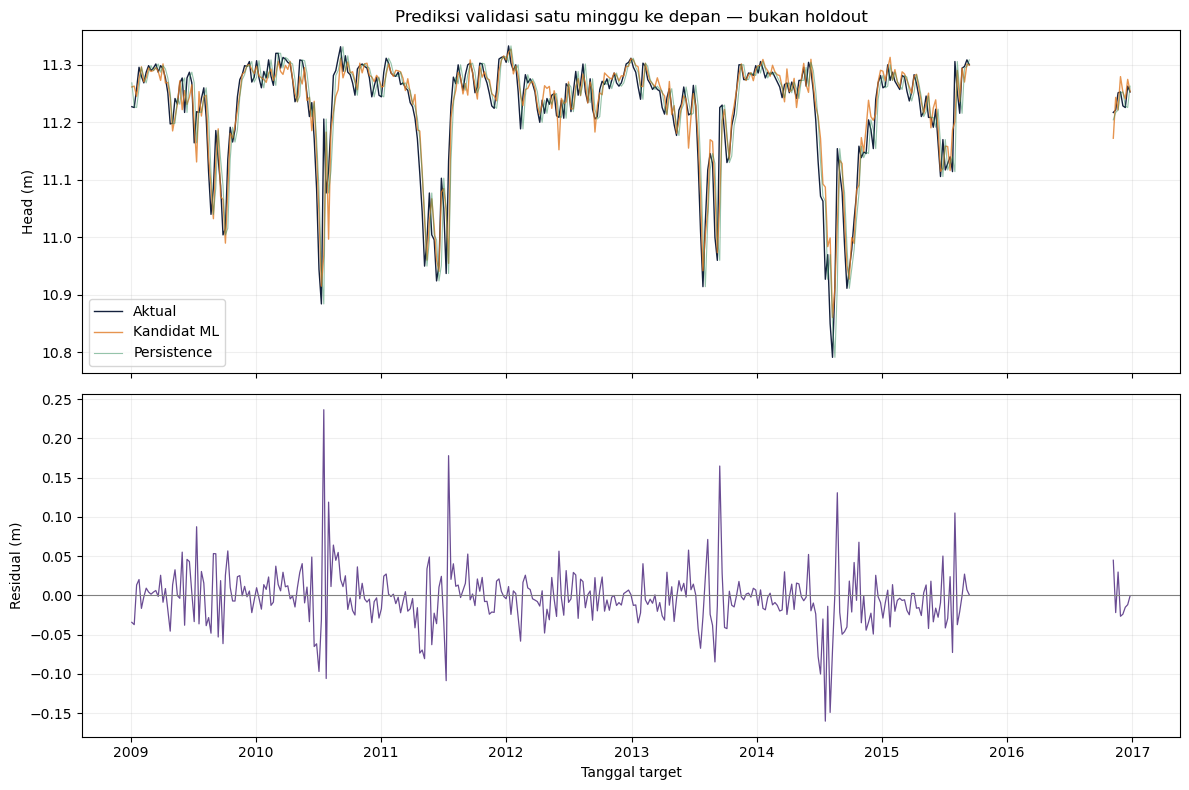

MAE kandidat ML: 0.0248 m
MAE persistence: 0.0334 m
Rekomendasi sementara pada cakupan penuh: kandidat_ml
Ini keputusan validasi. Belum ada kesimpulan performa holdout atau kelayakan lapangan.


In [8]:
oof_terpilih = cache_oof[ID_TERPILIH].copy()
tabel_log_fold = pd.DataFrame(log_fold)
fold_terpilih = tabel_log_fold.loc[tabel_log_fold["experiment_id"] == ID_TERPILIH].copy()
display(fold_terpilih[["fold", "n", "train_MAE_m", "MAE_m", "RMSE_m", "R2"]].round(4))

evaluasi_irisan = baseline_oof.loc[musiman_tersedia].copy()
evaluasi_irisan["prediksi_ml"] = oof_terpilih.loc[musiman_tersedia, "prediksi_m"].to_numpy()
tabel_irisan = pd.DataFrame([
    {"model": nama, **hitung_metrik(evaluasi_irisan[TARGET], evaluasi_irisan[kolom])}
    for nama, kolom in [("Persistence", "baseline_persistence"),
        ("Seasonal naive 52w", "baseline_seasonal_52w"), ("Kandidat ML", "prediksi_ml")]
])
print("Perbandingan pada irisan tanggal baseline musiman:")
display(tabel_irisan.round(4))

grafik = oof_terpilih.set_index("target_date")[[TARGET, "prediksi_m"]]
grafik["persistence"] = baseline_oof.set_index("target_date")["baseline_persistence"]
grafik = grafik.reindex(pd.date_range(grafik.index.min(), grafik.index.max(), freq="W-SUN"))
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(grafik.index, grafik[TARGET], label="Aktual", color="#14213D", linewidth=1)
axes[0].plot(grafik.index, grafik["prediksi_m"], label="Kandidat ML", color="#E07A24", alpha=.8, linewidth=1)
axes[0].plot(grafik.index, grafik["persistence"], label="Persistence", color="#2E8B57", alpha=.5, linewidth=.8)
axes[0].set(title="Prediksi validasi satu minggu ke depan — bukan holdout", ylabel="Head (m)")
axes[0].legend()
axes[1].plot(grafik.index, grafik[TARGET]-grafik["prediksi_m"], color="#6A4C93", linewidth=.9)
axes[1].axhline(0, color="grey", linewidth=.8)
axes[1].set(xlabel="Tanggal target", ylabel="Residual (m)")
for ax in axes:
    ax.grid(alpha=.2)
fig.tight_layout()
fig.savefig(OUTPUT_DIR/"02_prediksi_validasi.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)

rekomendasi_cv = "kandidat_ml" if terpilih["MAE_m"] < metrik_persistence["MAE_m"] else "persistence"
print("MAE kandidat ML:", round(float(terpilih["MAE_m"]), 4), "m")
print("MAE persistence:", round(metrik_persistence["MAE_m"], 4), "m")
print("Rekomendasi sementara pada cakupan penuh:", rekomendasi_cv)
print("Ini keputusan validasi. Belum ada kesimpulan performa holdout atau kelayakan lapangan.")


## 8. Mengunci Kandidat dan Menyimpan Pipeline

Saya melatih ulang kandidat ML dengan data pengembangan sebelum batas waktu prediksi holdout pertama. Dengan aturan konservatif yang sama, target latihan terakhir harus lebih awal daripada akhir minggu saat prediksi holdout pertama dibuat.

Pipeline disimpan bersama urutan fitur dan metadata. Jika persistence mengalahkan kandidat ML pada validasi, rekomendasi sementara tetap persistence; file ML tetap disimpan agar evaluasi akhir dapat membandingkan metode yang telah dikunci.

File model adalah hasil pelatihan pada pengembangan, bukan model yang sudah dilatih memakai holdout. Evaluasi akhir nantinya menggunakan model ini tanpa tuning ulang berdasarkan skor holdout.

Notebook ini belum membuat aplikasi. Dashboard nantinya harus menggunakan definisi fitur yang sama; mengunggah CSV mentah ke model tanpa preprocessing yang sesuai akan menghasilkan input yang keliru.


In [9]:
batas_fit_final = BATAS_HOLDOUT - pd.Timedelta(weeks=1)
fit_final = dev.loc[dev["target_date"] < batas_fit_final].copy()
assert not fit_final.empty and fit_final["target_date"].max() < batas_fit_final
pipeline_final = clone(registry[ID_TERPILIH])
with warnings.catch_warnings(record=True) as warning_final:
    warnings.simplefilter("always")
    pipeline_final.fit(fit_final[FITUR_TERPILIH], fit_final[TARGET])
warning_fit_final = [{"jenis": w.category.__name__, "pesan": str(w.message)} for w in warning_final]
if any(issubclass(w.category, ConvergenceWarning) for w in warning_final):
    raise RuntimeError("Fit final belum konvergen. Kandidat tidak disimpan; periksa konfigurasi sebelum evaluasi holdout.")

metadata = {
    "experiment_id": ID_TERPILIH, "model_family": terpilih["model"],
    "feature_group": terpilih["kelompok_fitur"], "feature_columns": FITUR_TERPILIH,
    "target_column": TARGET, "horizon_weeks": 1,
    "holdout_target_start": BATAS_HOLDOUT.strftime("%Y-%m-%d"),
    "fit_target_end": fit_final["target_date"].max().strftime("%Y-%m-%d"),
    "n_fit": len(fit_final), "seed": SEED, "versions": versi,
    "cv_MAE_m": float(terpilih["MAE_m"]), "cv_RMSE_m": float(terpilih["RMSE_m"]),
    "cv_persistence_MAE_m": metrik_persistence["MAE_m"],
    "provisional_recommendation": rekomendasi_cv,
    "selected_tuning_params": parameter_eksperimen.get(ID_TERPILIH, {}),
    "feature_schema": skema, "holdout_evaluated": False,
    "forecast_policy": skema["forecast_policy"],
    "warning_final_fit": warning_fit_final,
    "selection_note": "EDA and model/tuning selection use development; CV is exploratory, holdout is the final check."
}
paket_model = {"pipeline": pipeline_final, "metadata": metadata}
path_model = MODEL_DIR/"groundwater_ml_candidate.joblib"
joblib.dump(paket_model, path_model)
(MODEL_DIR/"model_metadata.json").write_text(json.dumps(metadata, indent=2, ensure_ascii=False), encoding="utf-8")

# Cek penyimpanan menggunakan contoh data pengembangan saja.
muat_ulang = joblib.load(path_model)
contoh = fit_final[FITUR_TERPILIH].tail(3)
np.testing.assert_allclose(pipeline_final.predict(contoh), muat_ulang["pipeline"].predict(contoh))
print("Pipeline disimpan dan diperiksa:", path_model.name)
print("Sampel fit final:", len(fit_final), "— target terakhir:", metadata["fit_target_end"])


Pipeline disimpan dan diperiksa: groundwater_ml_candidate.joblib
Sampel fit final: 803 — target terakhir: 2016-12-18


## 9. Menyimpan Hasil Eksperimen dan Catatan Pembelajaran

Tabel peringkat, hasil per fold, prediksi OOF, parameter tuning, warning, dan konfigurasi disimpan agar hasil dapat ditelusuri. Saya tidak hanya menyimpan satu angka terbaik tanpa mengetahui proses pemilihannya.

Skor validasi perlu dibaca bersama cakupan waktu dan baseline. Jika model tidak lebih baik daripada persistence, hasil tersebut tetap sah sebagai temuan. Jika lebih baik, manfaatnya masih perlu diperiksa pada holdout yang belum digunakan untuk memilih model.


In [10]:
tabel_fold.to_csv(OUTPUT_DIR/"fold_waktu.csv", index=False)
tabel_baseline.to_csv(OUTPUT_DIR/"baseline_cv.csv", index=False)
peringkat_awal.to_csv(OUTPUT_DIR/"perbandingan_awal.csv", index=False)
peringkat_semua.to_csv(OUTPUT_DIR/"peringkat_validasi.csv", index=False)
tabel_log_fold.to_csv(OUTPUT_DIR/"metrik_per_fold.csv", index=False)
perbandingan_fitur.to_csv(OUTPUT_DIR/"perbandingan_kelompok_fitur.csv")
tabel_irisan.to_csv(OUTPUT_DIR/"baseline_irisan_tanggal.csv", index=False)
oof_terpilih.to_csv(OUTPUT_DIR/"prediksi_oof_terpilih.csv", index=False)
pd.DataFrame(log_warning, columns=["experiment_id", "fold", "jenis", "pesan"]).to_csv(OUTPUT_DIR/"catatan_warning.csv", index=False)
(OUTPUT_DIR/"parameter_tuning.json").write_text(json.dumps(parameter_eksperimen, indent=2), encoding="utf-8")
ringkasan = [
    f"Eksperimen awal: {len(peringkat_awal)}; konfigurasi tuning: {len(hasil_tuning)}.",
    f"Kandidat ML: {ID_TERPILIH}, dengan {len(FITUR_TERPILIH)} fitur.",
    f"MAE OOF kandidat ML: {terpilih['MAE_m']:.4f} m; persistence: {metrik_persistence['MAE_m']:.4f} m.",
    f"Rekomendasi validasi sementara pada cakupan penuh: {rekomendasi_cv}.",
    f"Total warning tercatat: {len(log_warning)}. Eksperimen dengan warning konvergensi tidak dipilih.",
    "Holdout belum dievaluasi. Hasil validasi bukan skor pengujian akhir.",
    "Berikutnya: evaluasi kandidat terkunci dan baseline pada holdout, lalu dashboard serta dokumentasi."
]
(OUTPUT_DIR/"ringkasan_modeling.txt").write_text("\n".join(ringkasan), encoding="utf-8")
for kalimat in ringkasan:
    print(kalimat)


Eksperimen awal: 24; konfigurasi tuning: 14.
Kandidat ML: tuning_MLP_3, dengan 19 fitur.
MAE OOF kandidat ML: 0.0248 m; persistence: 0.0334 m.
Rekomendasi validasi sementara pada cakupan penuh: kandidat_ml.
Total warning tercatat: 1. Eksperimen dengan warning konvergensi tidak dipilih.
Holdout belum dievaluasi. Hasil validasi bukan skor pengujian akhir.
Berikutnya: evaluasi kandidat terkunci dan baseline pada holdout, lalu dashboard serta dokumentasi.


## 10. Apa yang Sudah Selesai dan Apa yang Belum?

Pada tahap ini saya sudah membuat fitur, membandingkan delapan algoritma, memeriksa manfaat kelompok fitur, mencoba tuning, dan menyimpan kandidat berdasarkan validasi waktu. Saya juga mempunyai baseline untuk memastikan model tidak hanya terlihat bagus karena head antarpekan saling berkaitan.

Namun, proyek belum selesai. Tahap berikutnya adalah **05 — evaluasi akhir**: membuka holdout satu kali untuk mengukur kandidat terkunci serta baseline pada tanggal yang sama, melihat kesalahan per periode, dan menulis batasannya. Hasil tersebut tidak dipakai untuk terus mengganti parameter lalu mengklaim holdout tetap independen.

Setelah evaluasi, barulah dibuat dashboard Streamlit, README berisi tujuan–data–metode–hasil–batasan, serta persiapan GitHub. Dashboard tetap berupa prototipe historis, bukan sistem keputusan keselamatan lereng atau monitoring real-time yang sudah tervalidasi.

### Lima hal yang perlu saya pahami

1. **Fitur:** informasi yang boleh diketahui ketika prediksi dibuat.
2. **Target:** head minggu berikutnya yang ingin diperkirakan.
3. **Baseline:** cara sederhana untuk menguji apakah ML menambah manfaat.
4. **Validasi:** tempat memilih model dan parameter; skornya bisa optimistis setelah banyak percobaan.
5. **Holdout:** pemeriksaan terakhir setelah keputusan model dikunci.

### Referensi teknis

- [Scikit-learn: mencegah data leakage dengan pipeline](https://scikit-learn.org/stable/common_pitfalls.html)
- [Scikit-learn: TransformedTargetRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.compose.TransformedTargetRegressor.html)
- [Scikit-learn: MLPRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html)

Sumber dataset dan konteks lokasi tetap mengikuti notebook 01. Referensi teknis membantu menjelaskan implementasi, bukan menjamin bahwa model tertentu pasti unggul.
